In [3]:
# 시각화에 사용할 BigQuery 결과 파일 업로드

from google.colab import files

uploaded = files.upload()

Saving 10_funnel_rates.csv to 10_funnel_rates (1).csv
Saving 12_device_funnel_rates.csv to 12_device_funnel_rates (1).csv
Saving 15_cohort_retention_summary.csv to 15_cohort_retention_summary (1).csv
Saving 17_monthly_purchase_kpis.csv to 17_monthly_purchase_kpis (1).csv
Saving 18_top_products_by_revenue.csv to 18_top_products_by_revenue (1).csv
Saving 19_repeat_purchase_rate.csv to 19_repeat_purchase_rate (1).csv


In [4]:
# 업로드된 파일 이름 확인

import os

os.listdir('/content')

['.config',
 '18_top_products_by_revenue (1).csv',
 '17_monthly_purchase_kpis (1).csv',
 '19_repeat_purchase_rate.csv',
 '10_funnel_rates.csv',
 '18_top_products_by_revenue.csv',
 '19_repeat_purchase_rate (1).csv',
 '12_device_funnel_rates.csv',
 '15_cohort_retention_summary (1).csv',
 '10_funnel_rates (1).csv',
 '12_device_funnel_rates (1).csv',
 '15_cohort_retention_summary.csv',
 '17_monthly_purchase_kpis.csv',
 'sample_data']

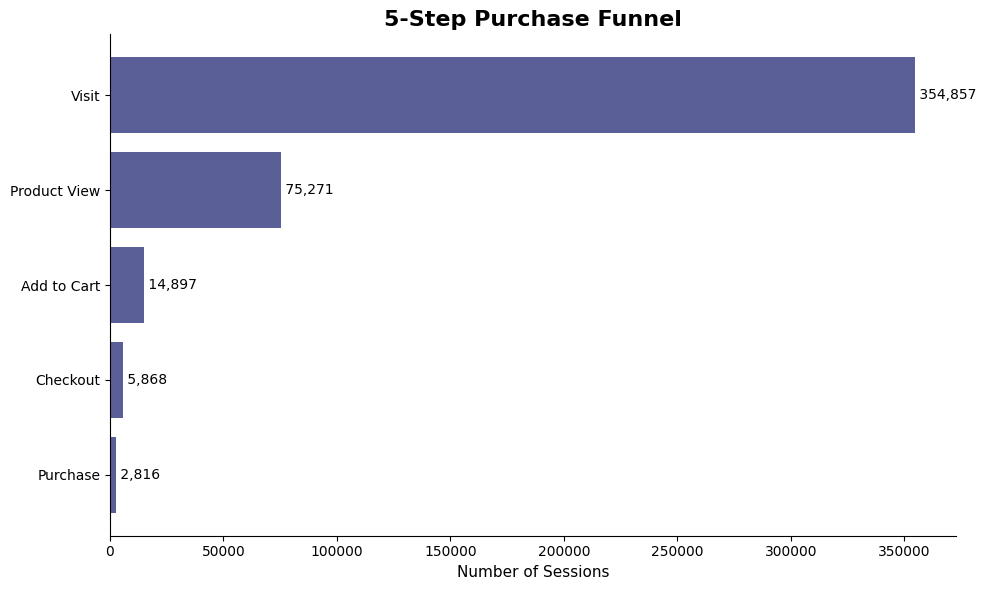

In [19]:
# 5단계 구매 퍼널 차트 만들기

import pandas as pd
import matplotlib.pyplot as plt

# BigQuery에서 저장한 퍼널 결과 불러오기
funnel = pd.read_csv('/content/10_funnel_rates.csv')

# 그래프에 표시할 단계 이름
stage_labels = [
    'Visit',
    'Product View',
    'Add to Cart',
    'Checkout',
    'Purchase'
]

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 진한 보라색 가로 막대그래프 생성
bars = plt.barh(
    stage_labels,
    funnel['sessions'],
    color='#5B5F97'
)

# 방문 단계가 가장 위에 나오도록 순서 변경
plt.gca().invert_yaxis()

# 그래프 제목과 축 이름
plt.title(
    '5-Step Purchase Funnel',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Number of Sessions',
    fontsize=11
)

# 막대 옆에 세션 수 표시
for bar, value in zip(bars, funnel['sessions']):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f' {value:,.0f}',
        va='center',
        fontsize=10
    )

# 불필요한 테두리 제거
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# 그래프를 고화질 이미지로 저장
plt.savefig(
    '/content/01_funnel_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
from google.colab import files

files.download('/content/01_funnel_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

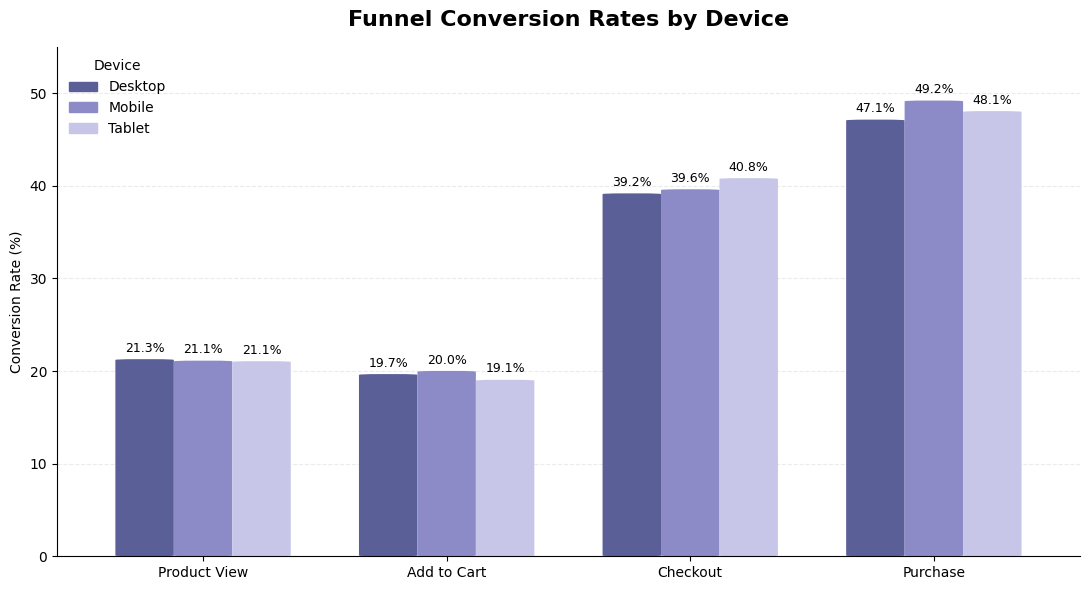

In [16]:
# 기기별 퍼널 전환율 비교 차트

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import Patch

# BigQuery 결과 불러오기
device = pd.read_csv('/content/12_device_funnel_rates.csv')

# 기기 표시 순서 설정
device = (
    device
    .set_index('device')
    .loc[['desktop', 'mobile', 'tablet']]
    .reset_index()
)

# 비교할 전환율
rate_columns = [
    'view_rate',
    'cart_rate',
    'checkout_rate',
    'purchase_rate'
]

stage_labels = [
    'Product View',
    'Add to Cart',
    'Checkout',
    'Purchase'
]

# 막대 위치와 너비
x = np.arange(len(stage_labels))
width = 0.24

# 연두색 팔레트
colors = {
    'desktop': '#5B5F97',
    'mobile': '#8D8BC7',
    'tablet': '#C7C6E8'
}

fig, ax = plt.subplots(figsize=(11, 6))

# 둥근 막대를 만드는 함수
def add_rounded_bars(positions, values, color):
    rounded_bars = []

    for position, value in zip(positions, values):
        bar = FancyBboxPatch(
            (position - width / 2, 0),
            width,
            value,
            boxstyle='round,pad=0,rounding_size=0.08',
            linewidth=0,
            facecolor=color
        )

        ax.add_patch(bar)
        rounded_bars.append(bar)

    return rounded_bars

# 기기별 막대 생성
for index, row in device.iterrows():
    positions = x + (index - 1) * width
    values = row[rate_columns].astype(float).values

    rounded_bars = add_rounded_bars(
        positions,
        values,
        colors[row['device']]
    )

    # 막대 위에 전환율 표시
    for position, value in zip(positions, values):
        ax.text(
            position,
            value + 0.8,
            f'{value:.1f}%',
            ha='center',
            fontsize=9
        )

# 그래프 제목과 축
ax.set_title(
    'Funnel Conversion Rates by Device',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_ylabel('Conversion Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylim(0, 55)
ax.set_xlim(-0.6, len(stage_labels) - 0.4)

# 연한 가로선
ax.yaxis.grid(
    True,
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# 범례
legend_items = [
    Patch(color=colors['desktop'], label='Desktop'),
    Patch(color=colors['mobile'], label='Mobile'),
    Patch(color=colors['tablet'], label='Tablet')
]

ax.legend(
    handles=legend_items,
    title='Device',
    frameon=False
)

# 불필요한 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 기존 파일을 새 디자인으로 교체
plt.savefig(
    '/content/02_device_funnel_rates.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
from google.colab import files

files.download('/content/02_device_funnel_rates.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

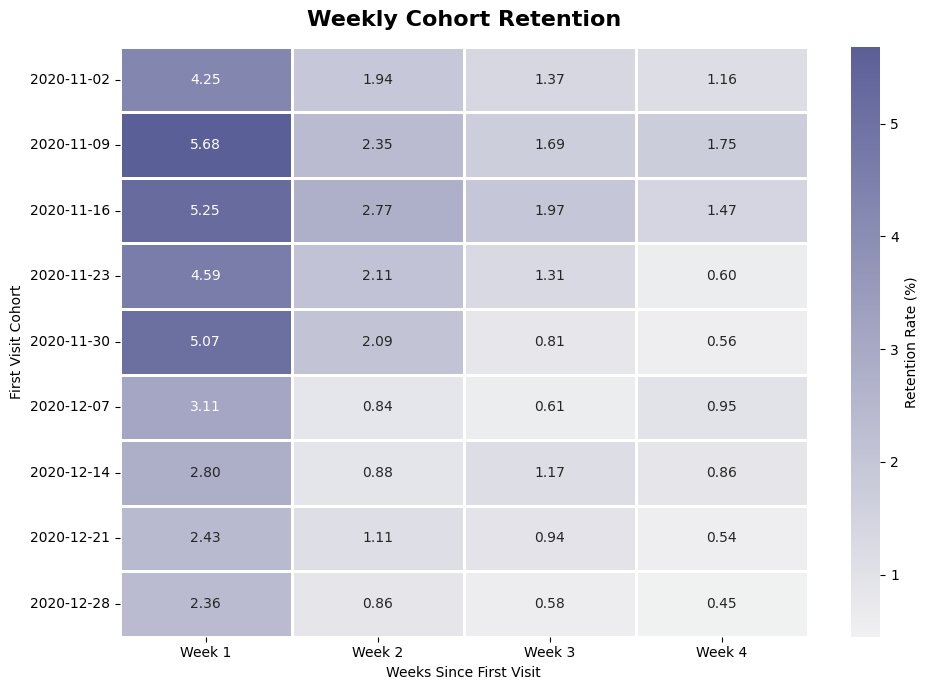

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. 코호트 분석 결과 불러오기
cohort = pd.read_csv('/content/15_cohort_retention_summary.csv')

# 2. 날짜를 보기 좋게 변경
cohort['cohort_week'] = pd.to_datetime(
    cohort['cohort_week']
).dt.strftime('%Y-%m-%d')

# 3. 1~4주 차 리텐션만 선택
retention = cohort.set_index('cohort_week')[
    ['week_1', 'week_2', 'week_3', 'week_4']
]

# 4. 보라색 팔레트 설정
purple_cmap = sns.light_palette('#5B5F97', as_cmap=True)

# 5. 히트맵 그리기
plt.figure(figsize=(10, 7))

sns.heatmap(
    retention,
    annot=True,
    fmt='.2f',
    cmap=purple_cmap,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title(
    'Weekly Cohort Retention',
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel('Weeks Since First Visit')
plt.ylabel('First Visit Cohort')
plt.xticks(
    ticks=[0.5, 1.5, 2.5, 3.5],
    labels=['Week 1', 'Week 2', 'Week 3', 'Week 4'],
    rotation=0
)
plt.yticks(rotation=0)
plt.tight_layout()

# 6. 코랩에 이미지 저장
plt.savefig(
    '/content/03_cohort_retention_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [20]:
from google.colab import files

files.download('/content/03_cohort_retention_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

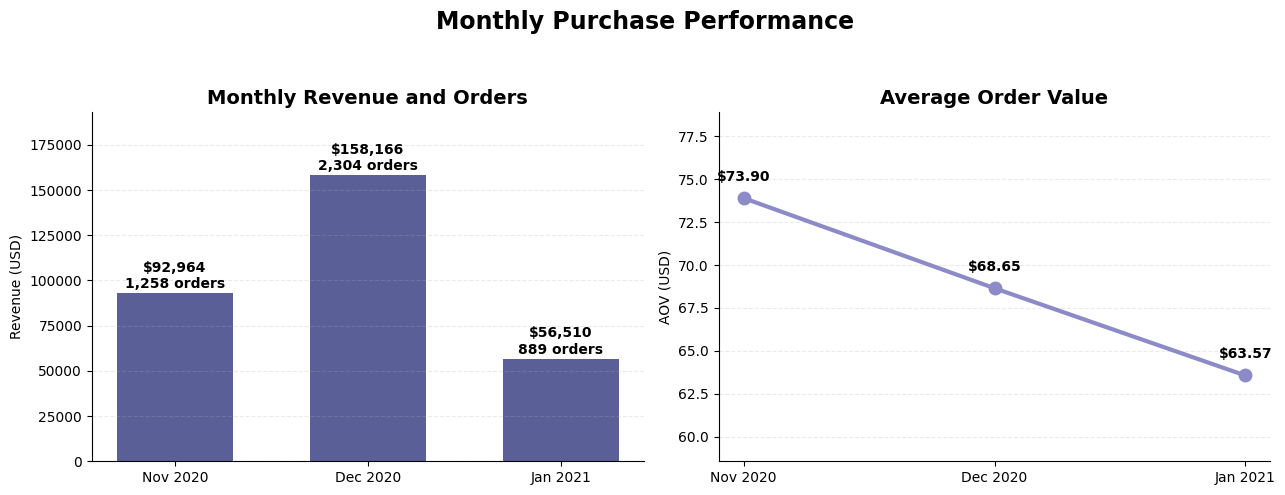

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1. 데이터 불러오기
monthly = pd.read_csv('/content/17_monthly_purchase_kpis.csv')

# 2. 월 이름 변경
monthly['month_label'] = pd.to_datetime(
    monthly['month']
).dt.strftime('%b %Y')

# 3. 평균 주문금액 직접 계산
monthly['aov'] = (
    monthly['total_revenue_usd']
    / monthly['order_count']
)

# 4. 그래프 영역 만들기
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dark_purple = '#5B5F97'
light_purple = '#8D8BC7'

# 왼쪽: 월별 매출과 주문 수
bars = axes[0].bar(
    monthly['month_label'],
    monthly['total_revenue_usd'],
    color=dark_purple,
    width=0.6
)

axes[0].set_title(
    'Monthly Revenue and Orders',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_ylim(
    0,
    monthly['total_revenue_usd'].max() * 1.22
)
axes[0].grid(axis='y', linestyle='--', alpha=0.25)
axes[0].spines[['top', 'right']].set_visible(False)

# 매출과 주문 수 표시
for bar, revenue, orders in zip(
    bars,
    monthly['total_revenue_usd'],
    monthly['order_count']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'${revenue:,.0f}\n{orders:,} orders',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# 오른쪽: 평균 주문금액
axes[1].plot(
    monthly['month_label'],
    monthly['aov'],
    marker='o',
    markersize=9,
    linewidth=3,
    color=light_purple
)

axes[1].set_title(
    'Average Order Value',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_ylabel('AOV (USD)')
axes[1].set_ylim(
    monthly['aov'].min() - 5,
    monthly['aov'].max() + 5
)
axes[1].grid(axis='y', linestyle='--', alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)

# 평균 주문금액 표시
for month, aov in zip(
    monthly['month_label'],
    monthly['aov']
):
    axes[1].text(
        month,
        aov + 1,
        f'${aov:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

fig.suptitle(
    'Monthly Purchase Performance',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# 이미지 저장
plt.savefig(
    '/content/04_monthly_purchase_performance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
files.download('/content/04_monthly_purchase_performance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

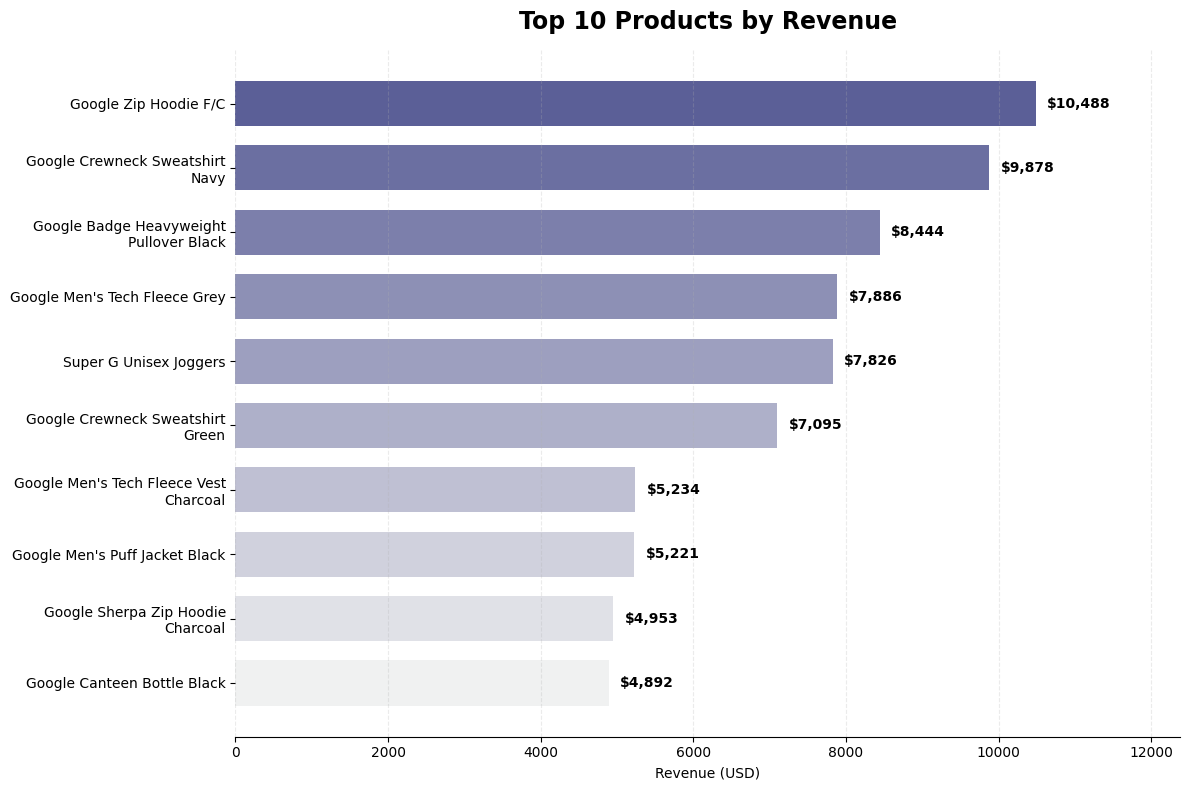

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from google.colab import files

# 1. 데이터 불러오기
products = pd.read_csv(
    '/content/18_top_products_by_revenue.csv'
)

# 2. 매출이 낮은 순서로 정렬
# 가로 그래프에서 매출 1위가 맨 위에 표시됨
products = products.sort_values('revenue_usd')

# 3. 긴 상품명을 줄바꿈
products['item_label'] = products['item_name'].apply(
    lambda name: '\n'.join(
        textwrap.wrap(str(name), width=30)
    )
)

# 4. 보라색 팔레트
colors = sns.light_palette(
    '#5B5F97',
    n_colors=len(products)
)

# 5. 그래프 만들기
plt.figure(figsize=(12, 8))

bars = plt.barh(
    products['item_label'],
    products['revenue_usd'],
    color=colors,
    height=0.7
)

# 6. 막대 끝에 매출 표시
for bar, revenue in zip(
    bars,
    products['revenue_usd']
):
    plt.text(
        bar.get_width() + 150,
        bar.get_y() + bar.get_height() / 2,
        f'${revenue:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top 10 Products by Revenue',
    fontsize=17,
    fontweight='bold',
    pad=15
)
plt.xlabel('Revenue (USD)')
plt.ylabel('')
plt.xlim(0, products['revenue_usd'].max() * 1.18)
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()

# 7. 코랩에 이미지 저장
plt.savefig(
    '/content/05_top_products_by_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [26]:
files.download(
    '/content/05_top_products_by_revenue.png'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

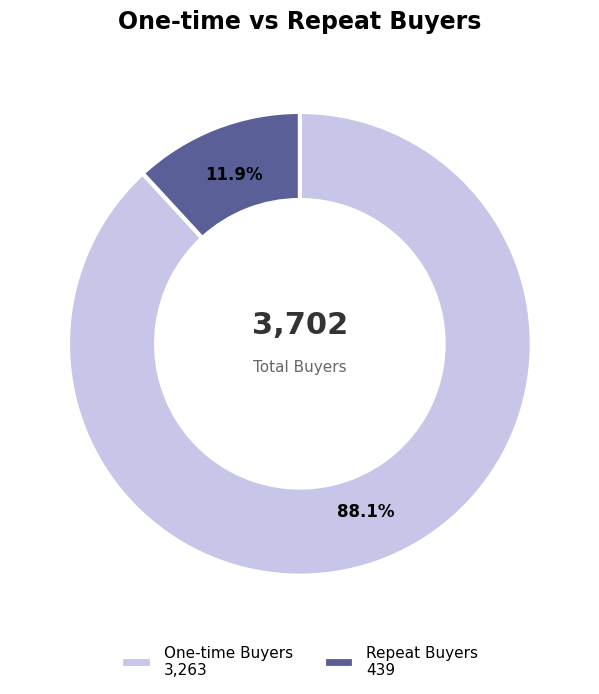

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1. 데이터 불러오기
repeat = pd.read_csv(
    '/content/19_repeat_purchase_rate.csv'
)

# 2. 첫 번째 행의 결과 가져오기
one_time_buyers = int(
    repeat.loc[0, 'one_time_buyers']
)

repeat_buyers = int(
    repeat.loc[0, 'repeat_buyers']
)

total_buyers = one_time_buyers + repeat_buyers

# 3. 그래프 데이터
sizes = [
    one_time_buyers,
    repeat_buyers
]

labels = [
    f'One-time Buyers\n{one_time_buyers:,}',
    f'Repeat Buyers\n{repeat_buyers:,}'
]

colors = [
    '#C7C6E8',
    '#5B5F97'
]

# 4. 도넛 차트 만들기
plt.figure(figsize=(8, 7))

wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct='%1.1f%%',
    pctdistance=0.78,
    wedgeprops={
        'width': 0.38,
        'edgecolor': 'white',
        'linewidth': 3
    },
    textprops={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)

# 5. 가운데 전체 구매자 수 표시
plt.text(
    0,
    0.08,
    f'{total_buyers:,}',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold',
    color='#333333'
)

plt.text(
    0,
    -0.10,
    'Total Buyers',
    ha='center',
    va='center',
    fontsize=11,
    color='#666666'
)

plt.title(
    'One-time vs Repeat Buyers',
    fontsize=17,
    fontweight='bold',
    pad=18
)

plt.legend(
    wedges,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout()

# 6. 코랩에 저장
plt.savefig(
    '/content/06_repeat_purchase_share.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
files.download(
    '/content/06_repeat_purchase_share.png'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>